# National Parks Visitation Analysis
## Individual Park Trends and Seasonality Analysis


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (16, 10)


## 1. Load and Clean Data


In [ ]:
# Load data
df = pd.read_csv('Datasets/national_parks.csv')

# Clean numeric columns
numeric_columns = ['RecreationVisits', 'NonRecreationVisits']
for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

df['RecreationVisits'] = df['RecreationVisits'].fillna(0)
df['NonRecreationVisits'] = df['NonRecreationVisits'].fillna(0)
df['TotalVisits'] = df['RecreationVisits'] + df['NonRecreationVisits']

print(f"Data loaded: {len(df)} records")
print(f"Parks: {df['ParkName'].nunique()}")
print(f"Years: {df['Year'].min()} - {df['Year'].max()}")


Data loaded: 34151 records
Parks: 63
Years: 1979 - 2024


/var/folders/y1/sdp6z2n512jfxp76fkhspjfc0000gn/T/ipykernel_50250/3613798514.py:2: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Datasets/national_parks.csv')


## 2. Cluster Parks by Size


In [ ]:
# Calculate total visitation per park
park_totals = df.groupby('ParkName')['TotalVisits'].sum().reset_index()
park_totals.columns = ['ParkName', 'TotalVisitsAllTime']

# Cluster into 4 size categories using quantiles
park_totals['SizeCategory'] = pd.qcut(park_totals['TotalVisitsAllTime'], 
                                        q=4, 
                                        labels=['Small', 'Medium', 'Large', 'Extra Large'])

# Merge back to main dataframe
df = df.merge(park_totals[['ParkName', 'SizeCategory']], on='ParkName', how='left')

print("Park distribution by size:")
print(park_totals['SizeCategory'].value_counts())
print(f"\nExtra Large parks: {park_totals[park_totals['SizeCategory']=='Extra Large']['TotalVisitsAllTime'].min():,.0f} - {park_totals[park_totals['SizeCategory']=='Extra Large']['TotalVisitsAllTime'].max():,.0f}")
print(f"Large parks: {park_totals[park_totals['SizeCategory']=='Large']['TotalVisitsAllTime'].min():,.0f} - {park_totals[park_totals['SizeCategory']=='Large']['TotalVisitsAllTime'].max():,.0f}")
print(f"Medium parks: {park_totals[park_totals['SizeCategory']=='Medium']['TotalVisitsAllTime'].min():,.0f} - {park_totals[park_totals['SizeCategory']=='Medium']['TotalVisitsAllTime'].max():,.0f}")
print(f"Small parks: {park_totals[park_totals['SizeCategory']=='Small']['TotalVisitsAllTime'].min():,.0f} - {park_totals[park_totals['SizeCategory']=='Small']['TotalVisitsAllTime'].max():,.0f}")


Park distribution by size:
SizeCategory
Small          16
Medium         16
Extra Large    16
Large          15
Name: count, dtype: int64

Extra Large parks: 92,890,436 - 895,608,088
Large parks: 39,353,231 - 88,350,565
Medium parks: 13,774,185 - 33,870,544
Small parks: 321,697 - 11,308,895


## 3. Calculate Average Monthly Visitation by Park


In [ ]:
# Calculate average visitation by park and month across all years
# Include ParkType so we can filter by it later
monthly_avg = df.groupby(['ParkName', 'ParkType', 'SizeCategory', 'Month'])['TotalVisits'].mean().reset_index()
monthly_avg.columns = ['ParkName', 'ParkType', 'SizeCategory', 'Month', 'AvgVisits']

print(f"Monthly averages calculated for {monthly_avg['ParkName'].nunique()} parks")
print(f"Park types: {monthly_avg['ParkType'].unique()}")
monthly_avg.head(12)


Monthly averages calculated for 63 parks
Park types: ['National Park']


/var/folders/y1/sdp6z2n512jfxp76fkhspjfc0000gn/T/ipykernel_50250/3189097364.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_avg = df.groupby(['ParkName', 'ParkType', 'SizeCategory', 'Month'])['TotalVisits'].mean().reset_index()


,ParkName,ParkType,SizeCategory,Month,AvgVisits
0,Acadia NP,National Park,Small,1,NaN
1,Acadia NP,National Park,Small,2,NaN
2,Acadia NP,National Park,Small,3,NaN
3,Acadia NP,National Park,Small,4,NaN
4,Acadia NP,National Park,Small,5,NaN
5,Acadia NP,National Park,Small,6,NaN
6,Acadia NP,National Park,Small,7,NaN
7,Acadia NP,National Park,Small,8,NaN
8,Acadia NP,National Park,Small,9,NaN
9,Acadia NP,National Park,Small,10,NaN


## 4. Line Graphs: Monthly Visitation by Park Size


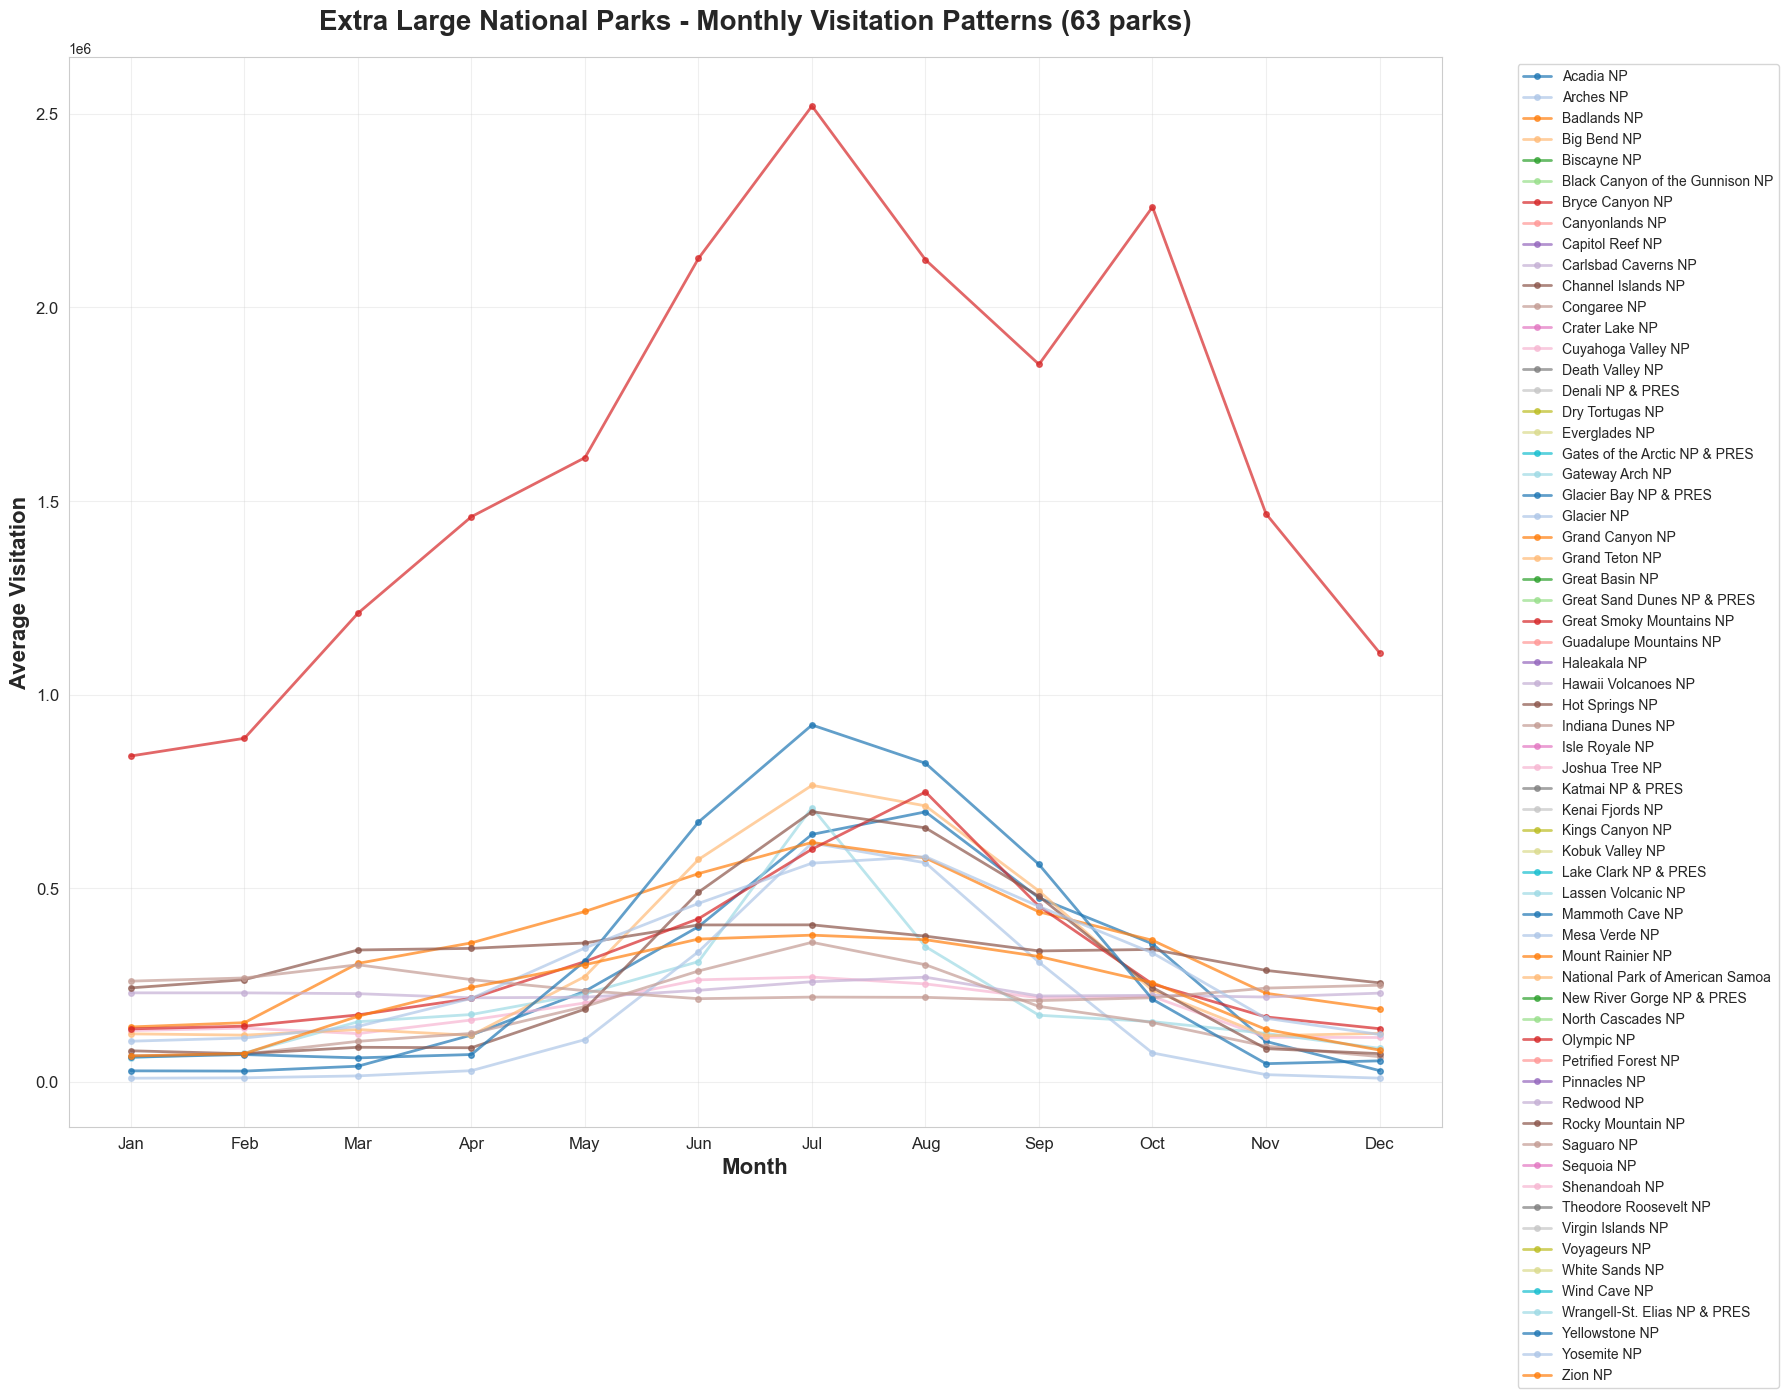

Extra Large National Parks: 63 parks plotted
Parks: Acadia NP, Arches NP, Badlands NP, Big Bend NP, Biscayne NP, Black Canyon of the Gunnison NP, Bryce Canyon NP, Canyonlands NP, Capitol Reef NP, Carlsbad Caverns NP, Channel Islands NP, Congaree NP, Crater Lake NP, Cuyahoga Valley NP, Death Valley NP, Denali NP & PRES, Dry Tortugas NP, Everglades NP, Gates of the Arctic NP & PRES, Gateway Arch NP, Glacier Bay NP & PRES, Glacier NP, Grand Canyon NP, Grand Teton NP, Great Basin NP, Great Sand Dunes NP & PRES, Great Smoky Mountains NP, Guadalupe Mountains NP, Haleakala NP, Hawaii Volcanoes NP, Hot Springs NP, Indiana Dunes NP, Isle Royale NP, Joshua Tree NP, Katmai NP & PRES, Kenai Fjords NP, Kings Canyon NP, Kobuk Valley NP, Lake Clark NP & PRES, Lassen Volcanic NP, Mammoth Cave NP, Mesa Verde NP, Mount Rainier NP, National Park of American Samoa, New River Gorge NP & PRES, North Cascades NP, Olympic NP, Petrified Forest NP, Pinnacles NP, Redwood NP, Rocky Mountain NP, Saguaro NP, Sequoi

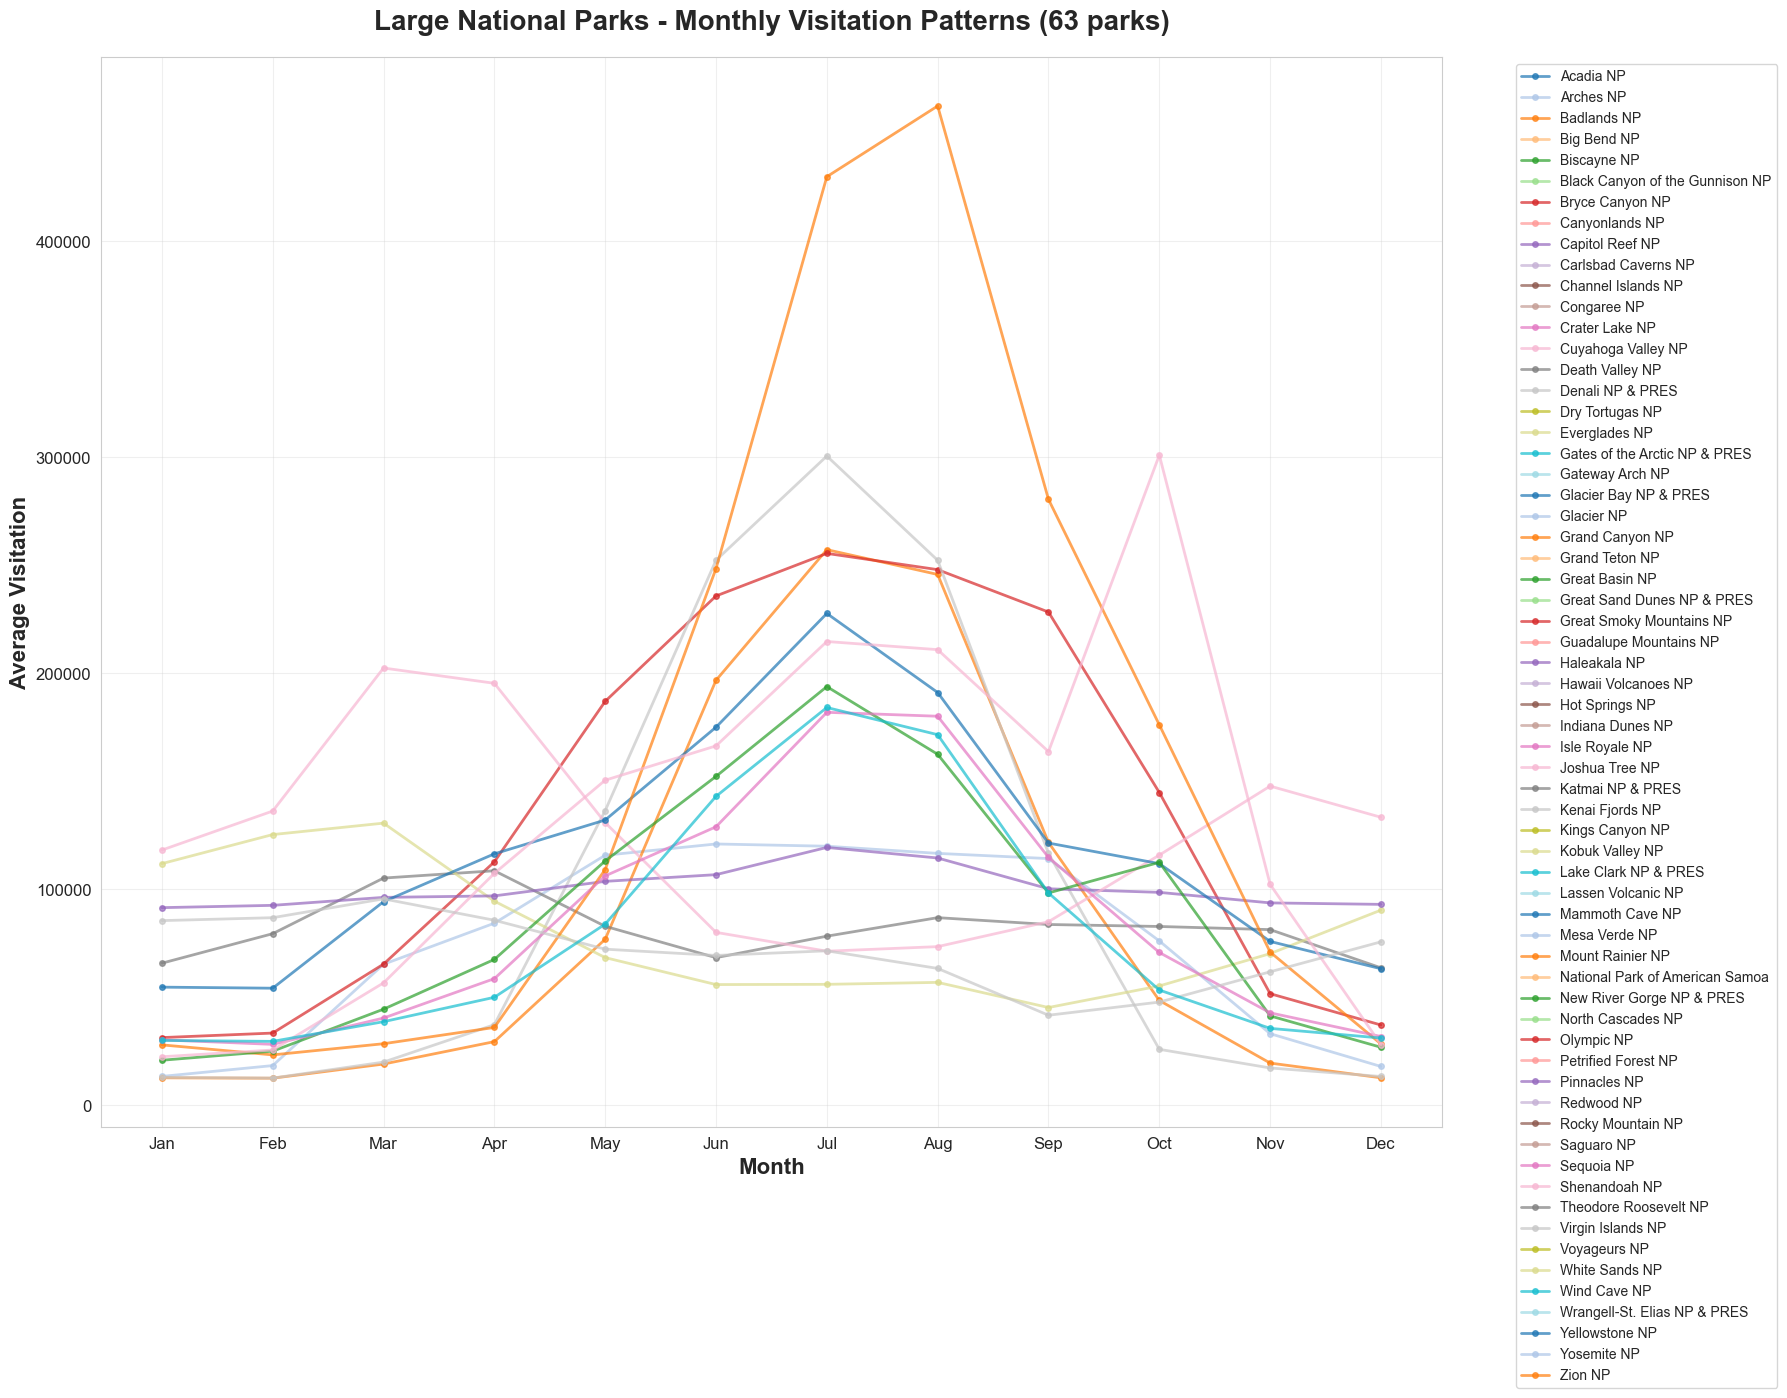

Large National Parks: 63 parks plotted
Parks: Acadia NP, Arches NP, Badlands NP, Big Bend NP, Biscayne NP, Black Canyon of the Gunnison NP, Bryce Canyon NP, Canyonlands NP, Capitol Reef NP, Carlsbad Caverns NP, Channel Islands NP, Congaree NP, Crater Lake NP, Cuyahoga Valley NP, Death Valley NP, Denali NP & PRES, Dry Tortugas NP, Everglades NP, Gates of the Arctic NP & PRES, Gateway Arch NP, Glacier Bay NP & PRES, Glacier NP, Grand Canyon NP, Grand Teton NP, Great Basin NP, Great Sand Dunes NP & PRES, Great Smoky Mountains NP, Guadalupe Mountains NP, Haleakala NP, Hawaii Volcanoes NP, Hot Springs NP, Indiana Dunes NP, Isle Royale NP, Joshua Tree NP, Katmai NP & PRES, Kenai Fjords NP, Kings Canyon NP, Kobuk Valley NP, Lake Clark NP & PRES, Lassen Volcanic NP, Mammoth Cave NP, Mesa Verde NP, Mount Rainier NP, National Park of American Samoa, New River Gorge NP & PRES, North Cascades NP, Olympic NP, Petrified Forest NP, Pinnacles NP, Redwood NP, Rocky Mountain NP, Saguaro NP, Sequoia NP, 

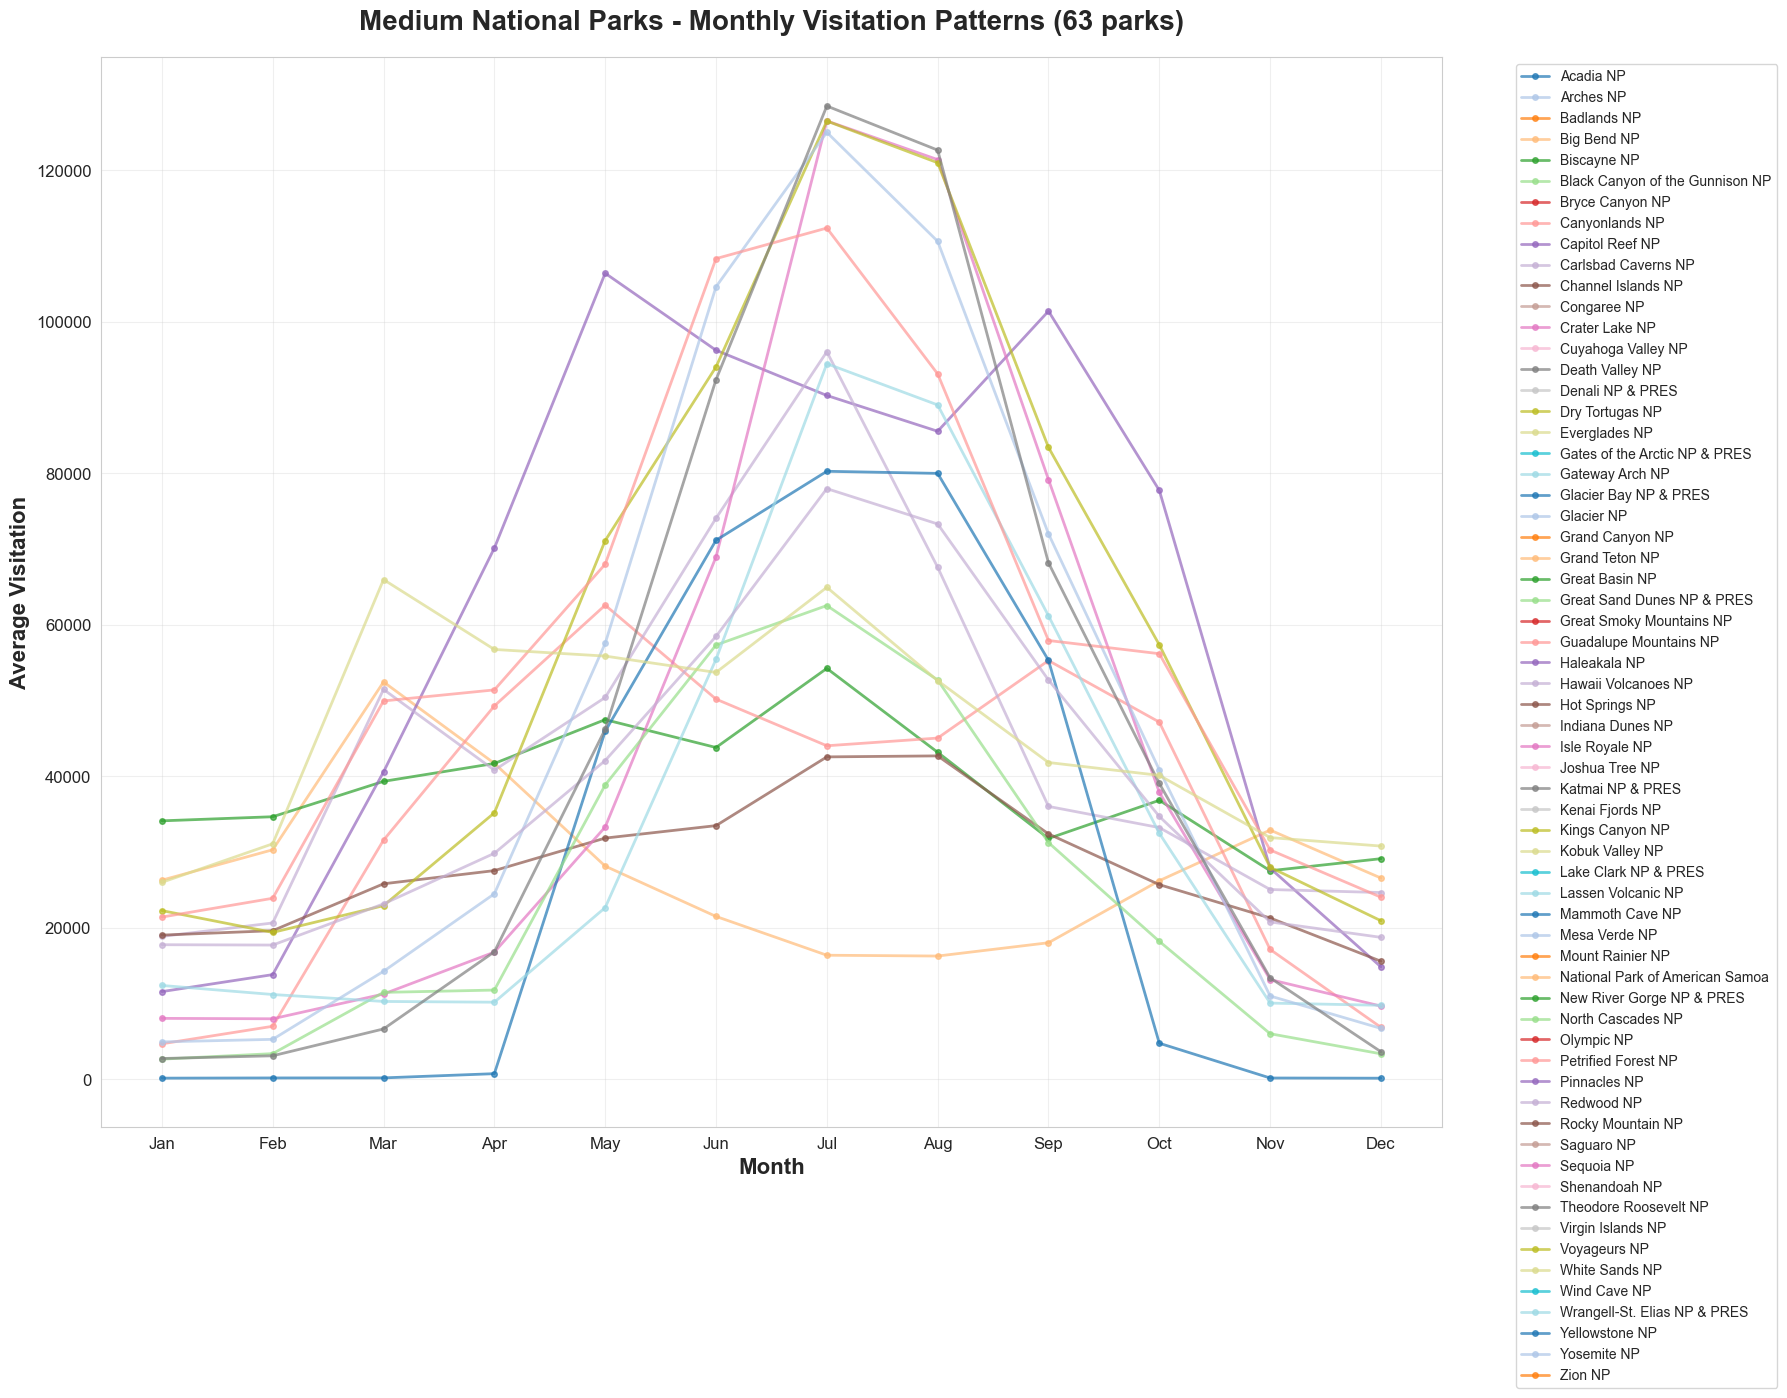

Medium National Parks: 63 parks plotted
Parks: Acadia NP, Arches NP, Badlands NP, Big Bend NP, Biscayne NP, Black Canyon of the Gunnison NP, Bryce Canyon NP, Canyonlands NP, Capitol Reef NP, Carlsbad Caverns NP, Channel Islands NP, Congaree NP, Crater Lake NP, Cuyahoga Valley NP, Death Valley NP, Denali NP & PRES, Dry Tortugas NP, Everglades NP, Gates of the Arctic NP & PRES, Gateway Arch NP, Glacier Bay NP & PRES, Glacier NP, Grand Canyon NP, Grand Teton NP, Great Basin NP, Great Sand Dunes NP & PRES, Great Smoky Mountains NP, Guadalupe Mountains NP, Haleakala NP, Hawaii Volcanoes NP, Hot Springs NP, Indiana Dunes NP, Isle Royale NP, Joshua Tree NP, Katmai NP & PRES, Kenai Fjords NP, Kings Canyon NP, Kobuk Valley NP, Lake Clark NP & PRES, Lassen Volcanic NP, Mammoth Cave NP, Mesa Verde NP, Mount Rainier NP, National Park of American Samoa, New River Gorge NP & PRES, North Cascades NP, Olympic NP, Petrified Forest NP, Pinnacles NP, Redwood NP, Rocky Mountain NP, Saguaro NP, Sequoia NP,

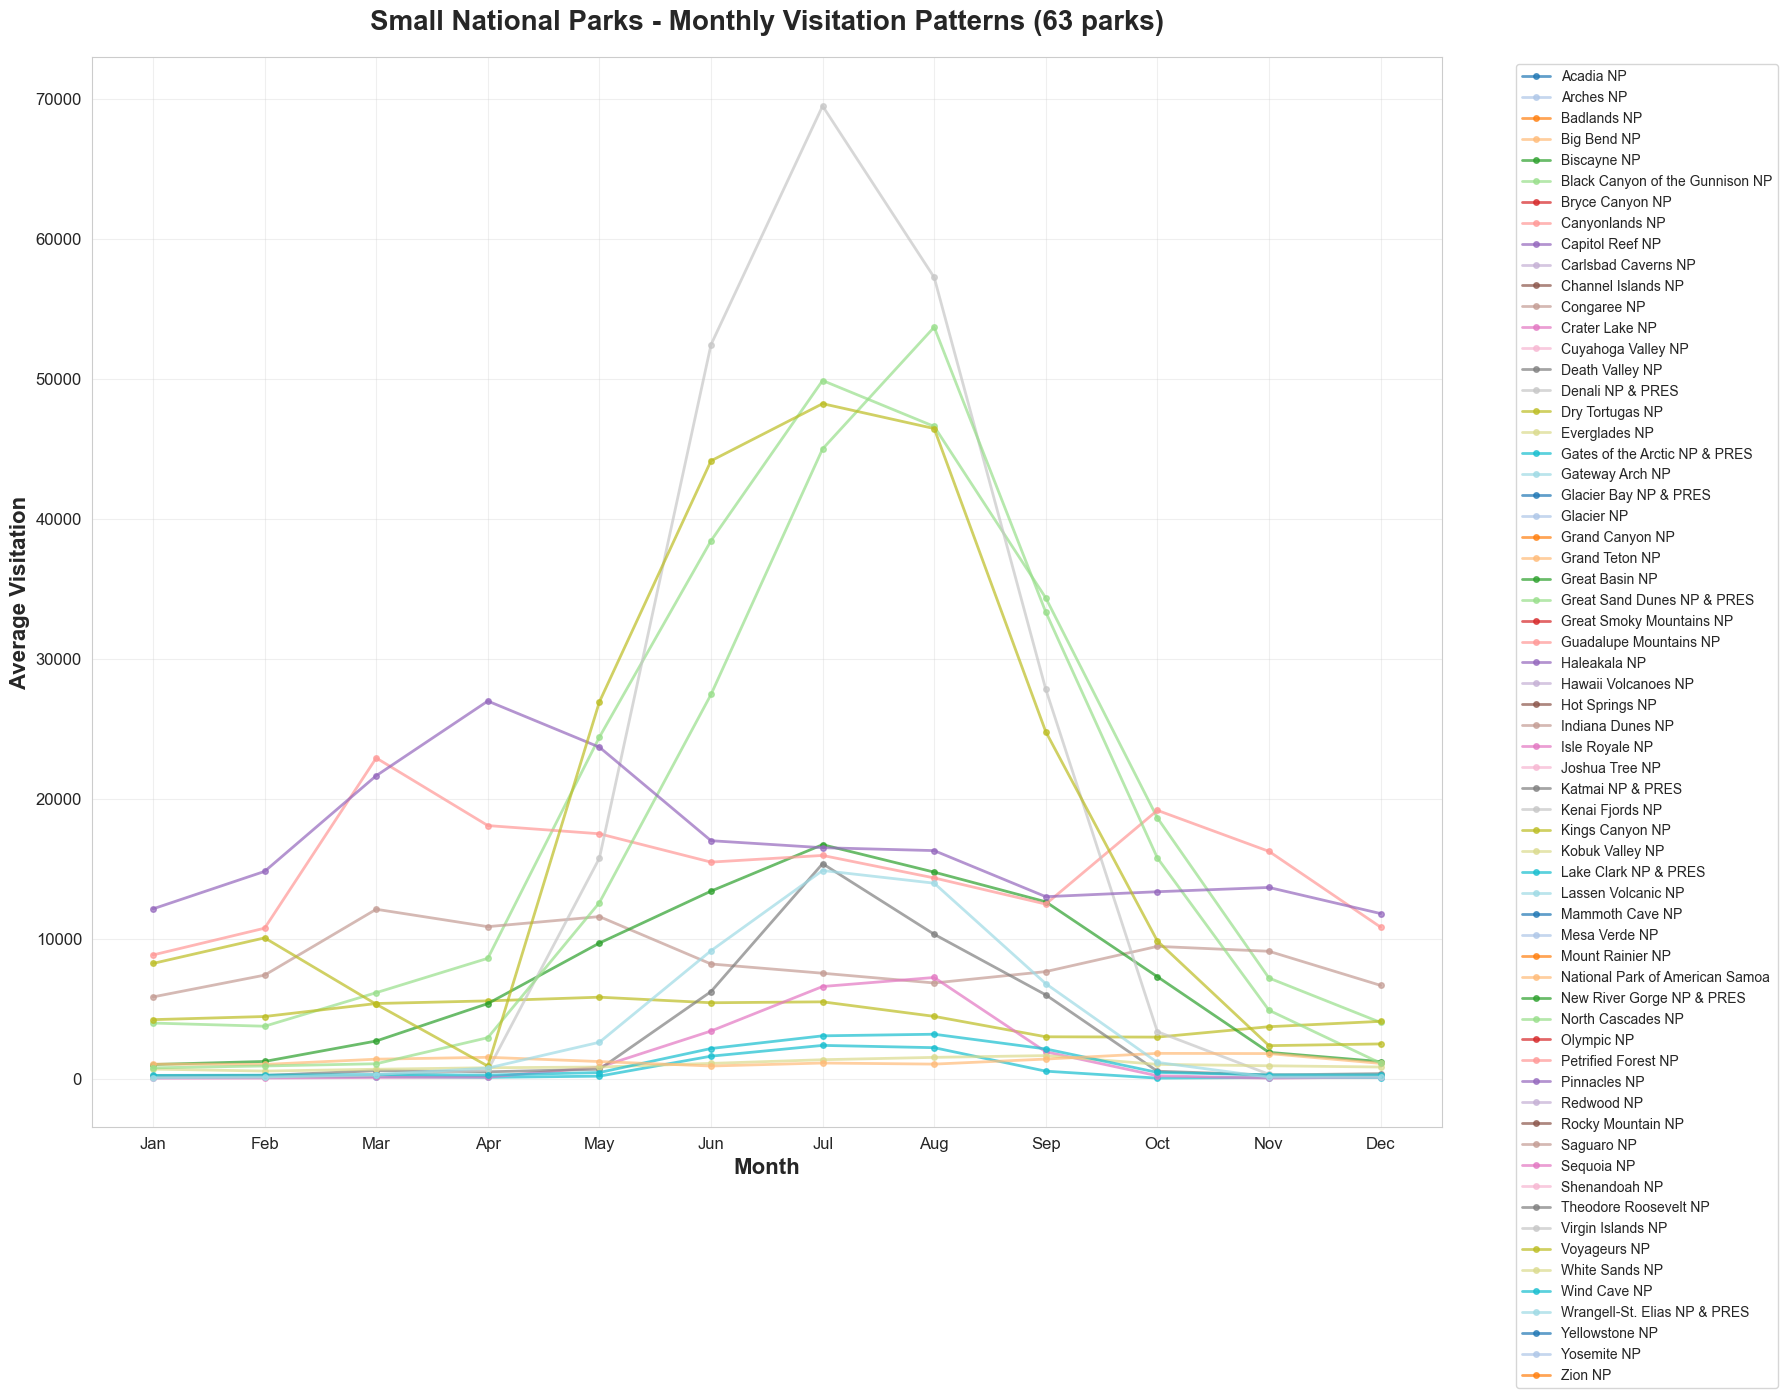

Small National Parks: 63 parks plotted
Parks: Acadia NP, Arches NP, Badlands NP, Big Bend NP, Biscayne NP, Black Canyon of the Gunnison NP, Bryce Canyon NP, Canyonlands NP, Capitol Reef NP, Carlsbad Caverns NP, Channel Islands NP, Congaree NP, Crater Lake NP, Cuyahoga Valley NP, Death Valley NP, Denali NP & PRES, Dry Tortugas NP, Everglades NP, Gates of the Arctic NP & PRES, Gateway Arch NP, Glacier Bay NP & PRES, Glacier NP, Grand Canyon NP, Grand Teton NP, Great Basin NP, Great Sand Dunes NP & PRES, Great Smoky Mountains NP, Guadalupe Mountains NP, Haleakala NP, Hawaii Volcanoes NP, Hot Springs NP, Indiana Dunes NP, Isle Royale NP, Joshua Tree NP, Katmai NP & PRES, Kenai Fjords NP, Kings Canyon NP, Kobuk Valley NP, Lake Clark NP & PRES, Lassen Volcanic NP, Mammoth Cave NP, Mesa Verde NP, Mount Rainier NP, National Park of American Samoa, New River Gorge NP & PRES, North Cascades NP, Olympic NP, Petrified Forest NP, Pinnacles NP, Redwood NP, Rocky Mountain NP, Saguaro NP, Sequoia NP, 

In [ ]:
# Create 4 separate line graphs (one for each size category)
# Filter to show ONLY National Parks (ParkType == 'National Park')
size_categories = ['Extra Large', 'Large', 'Medium', 'Small']
colors = plt.cm.tab20(np.linspace(0, 1, 20))

for size in size_categories:
    # Filter data for this size category - ONLY National Parks
    size_data = monthly_avg[
        (monthly_avg['SizeCategory'] == size) & 
        (monthly_avg['ParkType'] == 'National Park')
    ].copy()
    
    # Get unique parks for THIS size category only
    parks = sorted(size_data['ParkName'].unique())
    
    # Skip if no parks in this category
    if len(parks) == 0:
        print(f"No National Parks in {size} category, skipping...\n")
        continue
    
    # Create individual figure for each size category
    fig, ax = plt.subplots(figsize=(18, 14))
    
    # Plot ONLY the parks in this specific size category
    for i, park in enumerate(parks):
        park_data = size_data[size_data['ParkName'] == park].sort_values('Month')
        if len(park_data) > 0:  # Only plot if data exists
            ax.plot(park_data['Month'], park_data['AvgVisits'], 
                    marker='o', linewidth=2, markersize=4, 
                    label=park, alpha=0.7, color=colors[i % len(colors)])
    
    # Customize the plot
    ax.set_xlabel('Month', fontsize=16, fontweight='bold')
    ax.set_ylabel('Average Visitation', fontsize=16, fontweight='bold')
    ax.set_title(f'{size} National Parks - Monthly Visitation Patterns ({len(parks)} parks)', 
                 fontsize=20, fontweight='bold', pad=20)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    ax.grid(True, alpha=0.3)
    
    # Get handles and labels from what was actually plotted
    handles, labels = ax.get_legend_handles_labels()
    # Create legend with only the plotted items
    if len(handles) > 0:
        ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left', 
                 fontsize=10, ncol=1)
    
    ax.tick_params(axis='both', labelsize=12)
    
    plt.tight_layout()
    plt.show()
    

## 5. Determine Seasonality for Each Park


In [ ]:
# Define seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:  # 9, 10, 11
        return 'Fall'

monthly_avg['Season'] = monthly_avg['Month'].apply(get_season)

# Calculate average visitation by season for each park
seasonal_avg = monthly_avg.groupby(['ParkName', 'SizeCategory', 'Season'])['AvgVisits'].mean().reset_index()

# Find peak season for each park
park_seasonality = []

for park in seasonal_avg['ParkName'].unique():
    park_data = seasonal_avg[seasonal_avg['ParkName'] == park]
    
    # Peak season
    peak_season = park_data.loc[park_data['AvgVisits'].idxmax(), 'Season']
    peak_visits = park_data['AvgVisits'].max()
    
    # Low season
    low_season = park_data.loc[park_data['AvgVisits'].idxmin(), 'Season']
    low_visits = park_data['AvgVisits'].min()
    
    # Seasonal variation
    if low_visits > 0:
        variation_pct = ((peak_visits - low_visits) / low_visits) * 100
    else:
        variation_pct = np.inf
    
    # Size category
    size_cat = park_data['SizeCategory'].iloc[0]
    
    park_seasonality.append({
        'ParkName': park,
        'SizeCategory': size_cat,
        'PeakSeason': peak_season,
        'PeakVisits': peak_visits,
        'LowSeason': low_season,
        'LowVisits': low_visits,
        'SeasonalVariation%': variation_pct
    })

seasonality_df = pd.DataFrame(park_seasonality)
seasonality_df = seasonality_df.sort_values('PeakVisits', ascending=False)

print(f"Seasonality analysis completed for {len(seasonality_df)} parks\\n")
seasonality_df.head(20)


Seasonality analysis completed for 63 parks\n


/var/folders/y1/sdp6z2n512jfxp76fkhspjfc0000gn/T/ipykernel_50250/1296759838.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seasonal_avg = monthly_avg.groupby(['ParkName', 'SizeCategory', 'Season'])['AvgVisits'].mean().reset_index()


,ParkName,SizeCategory,PeakSeason,PeakVisits,LowSeason,LowVisits,SeasonalVariation%
26,Great Smoky Mountains NP,Small,Summer,2.256696e+06,Winter,945888.021739,138.579582
60,Yellowstone NP,Small,Summer,8.052259e+05,Winter,63007.239130,1177.989578
23,Grand Teton NP,Small,Summer,6.843959e+05,Winter,123414.449275,454.550832
50,Rocky Mountain NP,Small,Summer,6.146282e+05,Winter,75365.355072,715.531518
46,Olympic NP,Small,Summer,5.903989e+05,Winter,139454.565217,323.362931
0,Acadia NP,Small,Summer,5.791790e+05,Winter,28541.144928,1929.277285
22,Grand Canyon NP,Small,Summer,5.782205e+05,Winter,161038.514493,259.057278
61,Yosemite NP,Small,Summer,5.358635e+05,Winter,113672.478261,371.410030
21,Glacier NP,Small,Summer,5.063445e+05,Winter,9951.521739,4988.111570
19,Gateway Arch NP,Small,Summer,4.561998e+05,Winter,74592.753623,511.587334


### Peak Season Distribution


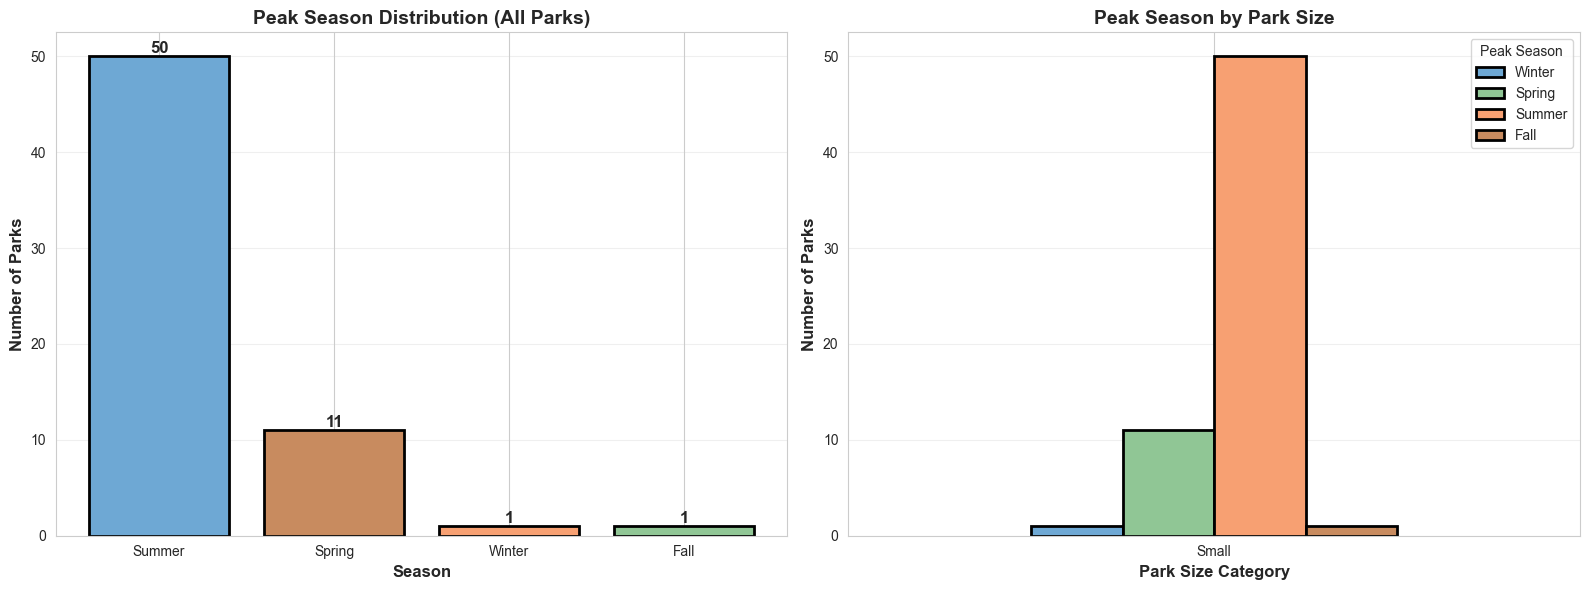

\nPeak Season Summary:
PeakSeason
Summer    50
Spring    11
Winter     1
Fall       1
Name: count, dtype: int64


In [ ]:
# Visualize peak season distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall peak season distribution
peak_counts = seasonality_df['PeakSeason'].value_counts()
axes[0].bar(peak_counts.index, peak_counts.values, 
            color=['#6EA8D4', '#C88B5F', '#F7A072', '#90C695'], edgecolor='black', linewidth=2)
axes[0].set_title('Peak Season Distribution (All Parks)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Season', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Parks', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for i, (season, count) in enumerate(peak_counts.items()):
    axes[0].text(i, count, str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

# Peak season by size category
peak_by_size = seasonality_df.groupby(['SizeCategory', 'PeakSeason']).size().unstack(fill_value=0)
peak_by_size = peak_by_size[['Winter', 'Spring', 'Summer', 'Fall']]
peak_by_size.plot(kind='bar', ax=axes[1], 
                  color=['#6EA8D4', '#90C695', '#F7A072', '#C88B5F'],
                  edgecolor='black', linewidth=2)
axes[1].set_title('Peak Season by Park Size', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Park Size Category', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Parks', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Peak Season', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\\nPeak Season Summary:")
print(seasonality_df['PeakSeason'].value_counts())


## 6. State Voting Patterns vs Park Visitation Changes


In [ ]:
# Load presidential voting data
voting_df = pd.read_csv('Datasets/1976-2020-president.csv')

print(f"Voting data loaded: {len(voting_df)} records")
print(f"Years covered: {voting_df['year'].min()} - {voting_df['year'].max()}")
print(f"States: {voting_df['state'].nunique()}")
print(f"\nColumns: {voting_df.columns.tolist()}")
voting_df.head()


Voting data loaded: 4287 records
Years covered: 1976 - 2020
States: 51

Columns: ['year', 'state', 'state_po', 'state_fips', 'state_cen', 'state_ic', 'office', 'candidate', 'party_detailed', 'writein', 'candidatevotes', 'totalvotes', 'version', 'notes', 'party_simplified']


,year,state,state_po,state_fips,state_cen,state_ic,office,candidate,party_detailed,writein,candidatevotes,totalvotes,version,notes,party_simplified
0,1976,ALABAMA,AL,1,63,41,US PRESIDENT,"CARTER, JIMMY",DEMOCRAT,False,659170,1182850,20210113,NaN,DEMOCRAT
1,1976,ALABAMA,AL,1,63,41,US PRESIDENT,"FORD, GERALD",REPUBLICAN,False,504070,1182850,20210113,NaN,REPUBLICAN
2,1976,ALABAMA,AL,1,63,41,US PRESIDENT,"MADDOX, LESTER",AMERICAN INDEPENDENT PARTY,False,9198,1182850,20210113,NaN,OTHER
3,1976,ALABAMA,AL,1,63,41,US PRESIDENT,"BUBAR, BENJAMIN """"BEN""""",PROHIBITION,False,6669,1182850,20210113,NaN,OTHER
4,1976,ALABAMA,AL,1,63,41,US PRESIDENT,"HALL, GUS",COMMUNIST PARTY USE,False,1954,1182850,20210113,NaN,OTHER


In [ ]:
# Determine winner for each state in each election
# Get only the two major parties
major_parties = voting_df[voting_df['party_simplified'].isin(['DEMOCRAT', 'REPUBLICAN'])]

# Calculate total votes for each party by state and year
state_party_votes = major_parties.groupby(['year', 'state', 'party_simplified'])['candidatevotes'].sum().reset_index()

# Pivot to compare Democrat vs Republican votes
state_votes_pivot = state_party_votes.pivot(index=['year', 'state'], 
                                              columns='party_simplified', 
                                              values='candidatevotes').reset_index()
state_votes_pivot.columns.name = None
state_votes_pivot = state_votes_pivot.fillna(0)

# Determine winner
state_votes_pivot['Winner'] = state_votes_pivot.apply(
    lambda row: 'DEMOCRAT' if row['DEMOCRAT'] > row['REPUBLICAN'] else 'REPUBLICAN', axis=1
)

# Calculate margin
state_votes_pivot['TotalVotes'] = state_votes_pivot['DEMOCRAT'] + state_votes_pivot['REPUBLICAN']
state_votes_pivot['DemocratPct'] = state_votes_pivot['DEMOCRAT'] / state_votes_pivot['TotalVotes'] * 100
state_votes_pivot['RepublicanPct'] = state_votes_pivot['REPUBLICAN'] / state_votes_pivot['TotalVotes'] * 100
state_votes_pivot['Margin'] = abs(state_votes_pivot['DemocratPct'] - state_votes_pivot['RepublicanPct'])

print("Sample of state voting results:")
state_votes_pivot.head(10)


Sample of state voting results:


,year,state,DEMOCRAT,REPUBLICAN,Winner,TotalVotes,DemocratPct,RepublicanPct,Margin
0,1976,ALABAMA,659170,504070,DEMOCRAT,1163240,56.666724,43.333276,13.333448
1,1976,ALASKA,44058,71555,REPUBLICAN,115613,38.108171,61.891829,23.783658
2,1976,ARIZONA,295602,418642,REPUBLICAN,714244,41.386697,58.613303,17.226606
3,1976,ARKANSAS,498604,267903,DEMOCRAT,766507,65.048851,34.951149,30.097703
4,1976,CALIFORNIA,3742284,3882244,REPUBLICAN,7624528,49.082173,50.917827,1.835655
5,1976,COLORADO,460801,584278,REPUBLICAN,1045079,44.092456,55.907544,11.815088
6,1976,CONNECTICUT,647895,719261,REPUBLICAN,1367156,47.389983,52.610017,5.220033
7,1976,DELAWARE,122461,109780,DEMOCRAT,232241,52.730138,47.269862,5.460276
8,1976,DISTRICT OF COLUMBIA,137818,27873,DEMOCRAT,165691,83.177722,16.822278,66.355445
9,1976,FLORIDA,1636000,1469531,DEMOCRAT,3105531,52.680202,47.319798,5.360404


In [ ]:
# Classify states as Red, Blue, or Swing based on voting history
# Count how many times each state voted for each party
state_voting_summary = state_votes_pivot.groupby('state').agg({
    'Winner': lambda x: (x == 'REPUBLICAN').sum(),  # Count Republican wins
    'year': 'count'  # Total elections
}).reset_index()
state_voting_summary.columns = ['State', 'RepublicanWins', 'TotalElections']
state_voting_summary['DemocratWins'] = state_voting_summary['TotalElections'] - state_voting_summary['RepublicanWins']
state_voting_summary['RepublicanPct'] = state_voting_summary['RepublicanWins'] / state_voting_summary['TotalElections'] * 100

# Get state abbreviations from the original voting data
state_abbrev_mapping = voting_df[['state', 'state_po']].drop_duplicates()
state_voting_summary = state_voting_summary.merge(state_abbrev_mapping, left_on='State', right_on='state', how='left')
state_voting_summary = state_voting_summary.rename(columns={'state_po': 'StateAbbrev'})
state_voting_summary = state_voting_summary.drop('state', axis=1)

# Classify states:
# Red: >= 70% Republican wins
# Blue: <= 30% Republican wins (i.e., >= 70% Democrat wins)
# Swing: Between 30% and 70%
def classify_state(pct):
    if pct >= 70:
        return 'Red'
    elif pct <= 30:
        return 'Blue'
    else:
        return 'Swing'

state_voting_summary['StateCategory'] = state_voting_summary['RepublicanPct'].apply(classify_state)

# Override California to be a Blue state
state_voting_summary.loc[state_voting_summary['State'] == 'CALIFORNIA', 'StateCategory'] = 'Blue'

# Display classification
print("State Classification by Voting History (1976-2020):")
print(f"Red States: {(state_voting_summary['StateCategory'] == 'Red').sum()}")
print(f"Blue States: {(state_voting_summary['StateCategory'] == 'Blue').sum()}")
print(f"Swing States: {(state_voting_summary['StateCategory'] == 'Swing').sum()}")
print("\nBreakdown by category:")
for category in ['Red', 'Blue', 'Swing']:
    states = state_voting_summary[state_voting_summary['StateCategory'] == category]['State'].tolist()
    print(f"\n{category} States ({len(states)}): {', '.join(sorted(states))}")

state_voting_summary.head()


State Classification by Voting History (1976-2020):
Red States: 22
Blue States: 12
Swing States: 17

Breakdown by category:

Red States (22): ALABAMA, ALASKA, ARIZONA, ARKANSAS, IDAHO, INDIANA, KANSAS, KENTUCKY, LOUISIANA, MISSISSIPPI, MISSOURI, MONTANA, NEBRASKA, NORTH CAROLINA, NORTH DAKOTA, OKLAHOMA, SOUTH CAROLINA, SOUTH DAKOTA, TENNESSEE, TEXAS, UTAH, WYOMING

Blue States (12): CALIFORNIA, DELAWARE, DISTRICT OF COLUMBIA, HAWAII, MARYLAND, MASSACHUSETTS, MINNESOTA, NEW YORK, OREGON, RHODE ISLAND, WASHINGTON, WISCONSIN

Swing States (17): COLORADO, CONNECTICUT, FLORIDA, GEORGIA, ILLINOIS, IOWA, MAINE, MICHIGAN, NEVADA, NEW HAMPSHIRE, NEW JERSEY, NEW MEXICO, OHIO, PENNSYLVANIA, VERMONT, VIRGINIA, WEST VIRGINIA


,State,RepublicanWins,TotalElections,DemocratWins,RepublicanPct,StateAbbrev,StateCategory
0,ALABAMA,11,12,1,91.666667,AL,Red
1,ALASKA,12,12,0,100.000000,AK,Red
2,ARIZONA,10,12,2,83.333333,AZ,Red
3,ARKANSAS,9,12,3,75.000000,AR,Red
4,CALIFORNIA,4,12,8,33.333333,CA,Blue


In [ ]:
# Merge state voting classification with park data
# Park data uses state abbreviations (e.g., 'ME', 'CA')
# Voting summary now has StateAbbrev column from the state_po field
df_with_voting = df.merge(
    state_voting_summary[['StateAbbrev', 'StateCategory', 'RepublicanPct']], 
    left_on='State', 
    right_on='StateAbbrev', 
    how='left'
)

print(f"Parks by state voting category:")
park_state_summary = df_with_voting.groupby('StateCategory')['ParkName'].nunique().reset_index()
park_state_summary.columns = ['StateCategory', 'NumberOfParks']
print(park_state_summary)
print(f"\nParks with no state category (likely territories): {df_with_voting['StateCategory'].isna().sum()}")

# Show sample of merged data
print("\nSample of merged data:")
df_with_voting[['ParkName', 'State', 'StateCategory', 'RepublicanPct']].drop_duplicates().head(10)


Parks by state voting category:
  StateCategory  NumberOfParks
0          Blue             16
1           Red             30
2         Swing             15

Parks with no state category (likely territories): 804

Sample of merged data:


,ParkName,State,StateCategory,RepublicanPct
0,Acadia NP,ME,Swing,33.333333
552,Arches NP,UT,Red,100.000000
1104,Badlands NP,SD,Red,100.000000
1656,Big Bend NP,TX,Red,91.666667
2208,Biscayne NP,FL,Swing,66.666667
2760,Black Canyon of the Gunnison NP,CO,Swing,58.333333
3312,Bryce Canyon NP,UT,Red,100.000000
3864,Canyonlands NP,UT,Red,100.000000
4416,Capitol Reef NP,UT,Red,100.000000
4968,Carlsbad Caverns NP,NM,Swing,41.666667


In [ ]:
# Calculate visitation changes over time by state
# Group by state and year to get total annual visitation
state_year_visits = df_with_voting.groupby(['State', 'StateCategory', 'Year'])['TotalVisits'].sum().reset_index()

# Calculate changes for different time periods
# 1. Overall trend (from earliest to latest year for each state)
# 2. Recent changes (2015-2024 vs 2000-2009)

def calculate_visitation_change(group):
    """Calculate percentage change in visitation for a state"""
    group = group.sort_values('Year')
    
    # Overall change (first 5 years vs last 5 years)
    years = sorted(group['Year'].unique())
    if len(years) < 10:
        return None
    
    early_years = years[:5]
    late_years = years[-5:]
    
    early_avg = group[group['Year'].isin(early_years)]['TotalVisits'].mean()
    late_avg = group[group['Year'].isin(late_years)]['TotalVisits'].mean()
    
    if early_avg == 0:
        return None
    
    pct_change = ((late_avg - early_avg) / early_avg) * 100
    
    return {
        'EarlyPeriod': f"{min(early_years)}-{max(early_years)}",
        'LatePeriod': f"{min(late_years)}-{max(late_years)}",
        'EarlyAvg': early_avg,
        'LateAvg': late_avg,
        'PercentChange': pct_change,
        'AbsoluteChange': late_avg - early_avg
    }

# Calculate for each state
state_changes = []
for state in state_year_visits['State'].unique():
    state_data = state_year_visits[state_year_visits['State'] == state]
    change_data = calculate_visitation_change(state_data)
    
    if change_data:
        state_category = state_data['StateCategory'].iloc[0]
        state_changes.append({
            'State': state,
            'StateCategory': state_category,
            **change_data
        })

state_changes_df = pd.DataFrame(state_changes)

print("Visitation Changes by State:")
print(f"Total states with data: {len(state_changes_df)}")
print(f"\nSummary by State Category:")
summary = state_changes_df.groupby('StateCategory').agg({
    'PercentChange': ['mean', 'median', 'std'],
    'State': 'count'
}).round(2)
print(summary)

print("\nTop 10 states with largest visitation increase:")
print(state_changes_df.nlargest(10, 'PercentChange')[['State', 'StateCategory', 'PercentChange']].to_string(index=False))

print("\nTop 10 states with largest visitation decrease:")
print(state_changes_df.nsmallest(10, 'PercentChange')[['State', 'StateCategory', 'PercentChange']].to_string(index=False))

state_changes_df.head()


Visitation Changes by State:
Total states with data: 28

Summary by State Category:
              PercentChange                State
                       mean median     std count
StateCategory                                   
Blue                  27.10  23.19   20.31     5
Red                  131.24  76.57  248.24    14
Swing                126.89  52.27  158.78     9

Top 10 states with largest visitation increase:
State StateCategory  PercentChange
   SC           Red     921.376995
   WV         Swing     354.924983
   NV         Swing     334.313312
   OH         Swing     315.167519
   UT           Red     305.006612
   AK           Red     200.828815
   AZ           Red     133.569178
   TX           Red     100.653745
   TN           Red      93.099300
   WY           Red      86.797188

Top 10 states with largest visitation decrease:
State StateCategory  PercentChange
   KY           Red     -57.798326
   AR           Red     -54.245439
   MO           Red     -32.203122

,State,StateCategory,EarlyPeriod,LatePeriod,EarlyAvg,LateAvg,PercentChange,AbsoluteChange
0,AK,Red,1979-1983,2020-2024,700831.6,2108303.4,200.828815,1407471.8
1,AR,Red,1979-1983,2020-2024,5193898.8,2376445.6,-54.245439,-2817453.2
2,AZ,Red,1979-1983,2020-2024,4129550.0,9645356.0,133.569178,5515806.0
3,CA,Blue,1979-1983,2020-2024,6828921.4,10874564.2,59.242779,4045642.8
4,CO,Swing,1979-1983,2020-2024,3681402.8,5376143.2,46.035180,1694740.4


In [ ]:
# Correlation Analysis: State Voting Pattern vs Visitation Change
from scipy import stats

# Remove rows with missing state categories (territories)
correlation_df = state_changes_df.dropna(subset=['StateCategory'])

# Merge with Republican percentage for more granular analysis
correlation_df = correlation_df.merge(
    state_voting_summary[['StateAbbrev', 'RepublicanPct']], 
    left_on='State', 
    right_on='StateAbbrev', 
    how='left'
)

print("=== CORRELATION ANALYSIS ===\n")

# 1. Correlation between Republican voting percentage and visitation change
valid_data = correlation_df.dropna(subset=['RepublicanPct', 'PercentChange'])
if len(valid_data) > 2:
    corr_coef, p_value = stats.pearsonr(valid_data['RepublicanPct'], valid_data['PercentChange'])
    print(f"Pearson Correlation: Republican Voting % vs. Visitation Change %")
    print(f"  Correlation coefficient: {corr_coef:.4f}")
    print(f"  P-value: {p_value:.4f}")
    print(f"  Significant: {'Yes' if p_value < 0.05 else 'No'}")
    
    # Interpretation
    if abs(corr_coef) < 0.3:
        strength = "weak"
    elif abs(corr_coef) < 0.7:
        strength = "moderate"
    else:
        strength = "strong"
    
    direction = "positive" if corr_coef > 0 else "negative"
    
    print(f"  Interpretation: {strength.capitalize()} {direction} correlation")
    if corr_coef > 0:
        print(f"  States that vote more Republican tend to have larger increases in park visitation.")
    else:
        print(f"  States that vote more Democratic tend to have larger increases in park visitation.")

print("\n" + "="*60 + "\n")

# 2. Compare visitation changes across state categories (Red, Blue, Swing)
print("Visitation Change by State Political Category:\n")
for category in ['Red', 'Blue', 'Swing']:
    cat_data = correlation_df[correlation_df['StateCategory'] == category]
    if len(cat_data) > 0:
        print(f"{category} States:")
        print(f"  Count: {len(cat_data)}")
        print(f"  Mean change: {cat_data['PercentChange'].mean():.2f}%")
        print(f"  Median change: {cat_data['PercentChange'].median():.2f}%")
        print(f"  Std deviation: {cat_data['PercentChange'].std():.2f}%")
        print()

# 3. Statistical test: ANOVA to see if there's significant difference between categories
red_changes = correlation_df[correlation_df['StateCategory'] == 'Red']['PercentChange'].dropna()
blue_changes = correlation_df[correlation_df['StateCategory'] == 'Blue']['PercentChange'].dropna()
swing_changes = correlation_df[correlation_df['StateCategory'] == 'Swing']['PercentChange'].dropna()

if len(red_changes) > 0 and len(blue_changes) > 0 and len(swing_changes) > 0:
    f_stat, p_value_anova = stats.f_oneway(red_changes, blue_changes, swing_changes)
    print(f"ANOVA Test: Are visitation changes different across Red/Blue/Swing states?")
    print(f"  F-statistic: {f_stat:.4f}")
    print(f"  P-value: {p_value_anova:.4f}")
    print(f"  Significant difference: {'Yes' if p_value_anova < 0.05 else 'No'}")
    
print("\n" + "="*60)

correlation_df[['State', 'StateCategory', 'RepublicanPct', 'PercentChange']].head(10)


=== CORRELATION ANALYSIS ===

Pearson Correlation: Republican Voting % vs. Visitation Change %
  Correlation coefficient: 0.2387
  P-value: 0.2212
  Significant: No
  Interpretation: Weak positive correlation
  States that vote more Republican tend to have larger increases in park visitation.


Visitation Change by State Political Category:

Red States:
  Count: 14
  Mean change: 131.24%
  Median change: 76.57%
  Std deviation: 248.24%

Blue States:
  Count: 5
  Mean change: 27.10%
  Median change: 23.19%
  Std deviation: 20.31%

Swing States:
  Count: 9
  Mean change: 126.89%
  Median change: 52.27%
  Std deviation: 158.78%

ANOVA Test: Are visitation changes different across Red/Blue/Swing states?
  F-statistic: 0.5376
  P-value: 0.5907
  Significant difference: No



,State,StateCategory,RepublicanPct,PercentChange
0,AK,Red,100.000000,200.828815
1,AR,Red,75.000000,-54.245439
2,AZ,Red,83.333333,133.569178
3,CA,Blue,33.333333,59.242779
4,CO,Swing,58.333333,46.035180
5,FL,Swing,66.666667,52.274122
6,HI,Blue,8.333333,23.186462
7,IN,Red,91.666667,66.343878
8,KY,Red,75.000000,-57.798326
9,ME,Swing,33.333333,4.816783


/var/folders/y1/sdp6z2n512jfxp76fkhspjfc0000gn/T/ipykernel_50250/4017508629.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(data_for_box, labels=categories, patch_artist=True)


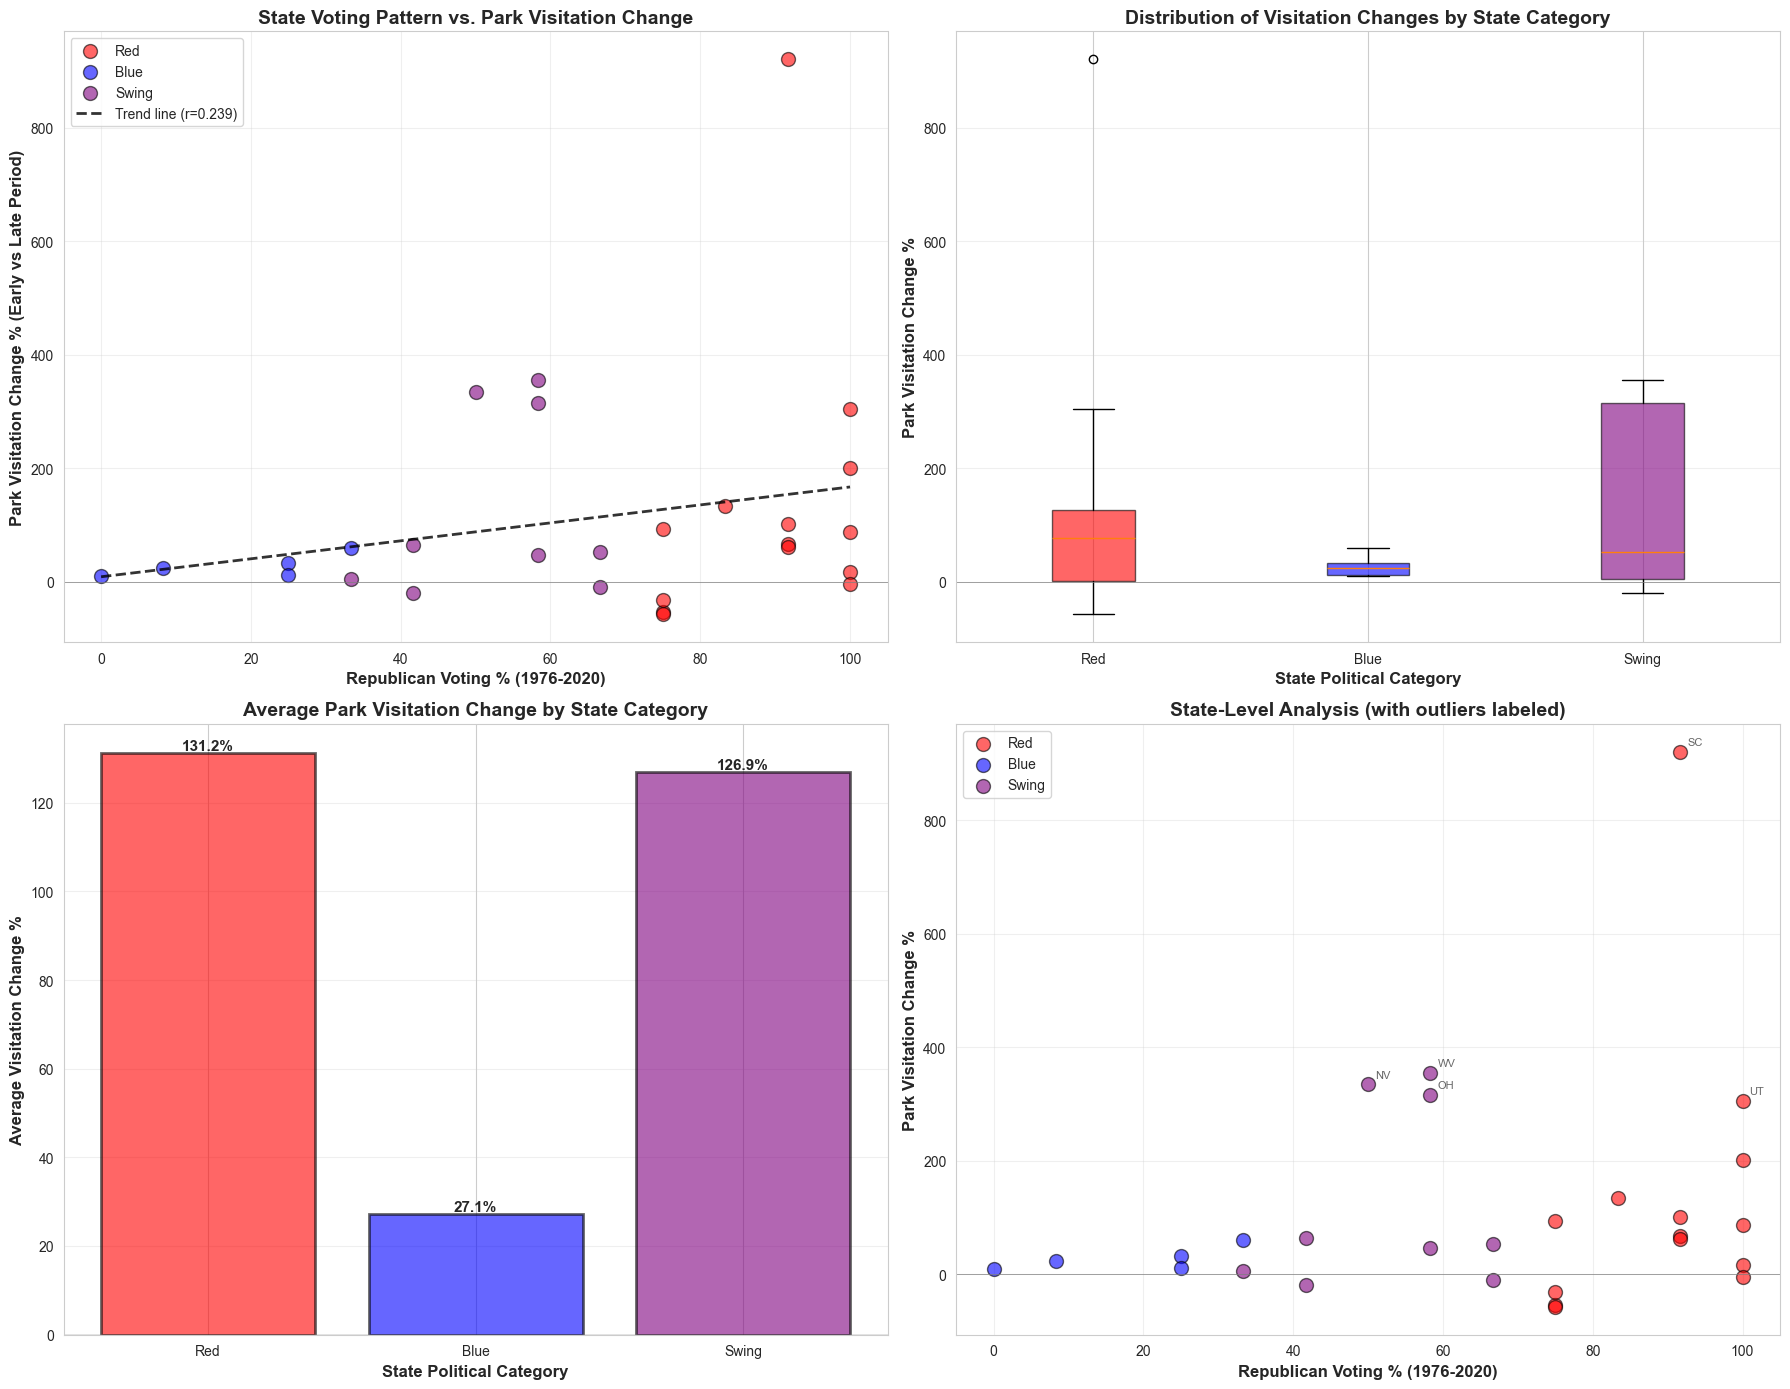

In [ ]:
# Visualization 1: Scatter plot of Republican voting % vs Visitation change
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Plot 1: Scatter plot with regression line
ax1 = axes[0, 0]
colors = {'Red': 'red', 'Blue': 'blue', 'Swing': 'purple'}
for category in ['Red', 'Blue', 'Swing']:
    cat_data = correlation_df[correlation_df['StateCategory'] == category]
    ax1.scatter(cat_data['RepublicanPct'], cat_data['PercentChange'], 
               c=colors[category], label=category, s=100, alpha=0.6, edgecolors='black')

# Add regression line
if len(valid_data) > 2:
    z = np.polyfit(valid_data['RepublicanPct'], valid_data['PercentChange'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(valid_data['RepublicanPct'].min(), valid_data['RepublicanPct'].max(), 100)
    ax1.plot(x_line, p(x_line), "k--", alpha=0.8, linewidth=2, label=f'Trend line (r={corr_coef:.3f})')

ax1.set_xlabel('Republican Voting % (1976-2020)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Park Visitation Change % (Early vs Late Period)', fontsize=12, fontweight='bold')
ax1.set_title('State Voting Pattern vs. Park Visitation Change', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

# Plot 2: Box plot by state category
ax2 = axes[0, 1]
categories = ['Red', 'Blue', 'Swing']
data_for_box = [correlation_df[correlation_df['StateCategory'] == cat]['PercentChange'].dropna() 
                for cat in categories]
bp = ax2.boxplot(data_for_box, labels=categories, patch_artist=True)
for patch, category in zip(bp['boxes'], categories):
    patch.set_facecolor(colors[category])
    patch.set_alpha(0.6)
ax2.set_ylabel('Park Visitation Change %', fontsize=12, fontweight='bold')
ax2.set_xlabel('State Political Category', fontsize=12, fontweight='bold')
ax2.set_title('Distribution of Visitation Changes by State Category', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

# Plot 3: Bar chart showing mean changes
ax3 = axes[1, 0]
mean_changes = correlation_df.groupby('StateCategory')['PercentChange'].mean().reindex(['Red', 'Blue', 'Swing'])
bars = ax3.bar(mean_changes.index, mean_changes.values, color=[colors[cat] for cat in mean_changes.index], 
               alpha=0.6, edgecolor='black', linewidth=2)
ax3.set_ylabel('Average Visitation Change %', fontsize=12, fontweight='bold')
ax3.set_xlabel('State Political Category', fontsize=12, fontweight='bold')
ax3.set_title('Average Park Visitation Change by State Category', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
ax3.axhline(y=0, color='gray', linestyle='-', linewidth=1)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top', 
            fontsize=11, fontweight='bold')

# Plot 4: State-level detail with labels
ax4 = axes[1, 1]
for category in ['Red', 'Blue', 'Swing']:
    cat_data = correlation_df[correlation_df['StateCategory'] == category]
    ax4.scatter(cat_data['RepublicanPct'], cat_data['PercentChange'], 
               c=colors[category], label=category, s=100, alpha=0.6, edgecolors='black')

# Add state labels for outliers
outlier_threshold = correlation_df['PercentChange'].std() * 1.5
outliers = correlation_df[abs(correlation_df['PercentChange']) > outlier_threshold]
for idx, row in outliers.iterrows():
    ax4.annotate(row['State'], (row['RepublicanPct'], row['PercentChange']),
                xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.7)

ax4.set_xlabel('Republican Voting % (1976-2020)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Park Visitation Change %', fontsize=12, fontweight='bold')
ax4.set_title('State-Level Analysis (with outliers labeled)', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()


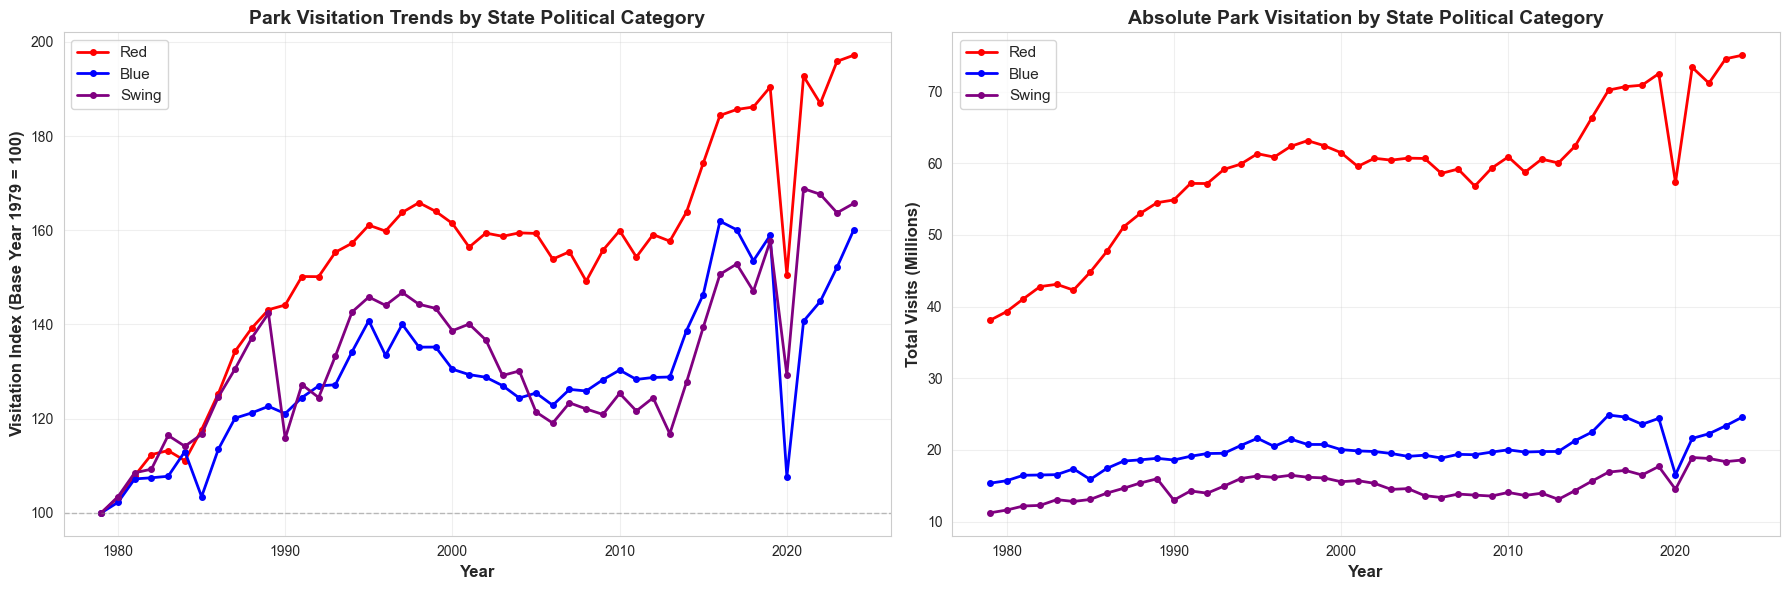

In [ ]:
# Visualization 2: Time series showing visitation trends by state category
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Aggregate visitation by state category and year
yearly_by_category = df_with_voting[df_with_voting['StateCategory'].notna()].groupby(
    ['Year', 'StateCategory']
)['TotalVisits'].sum().reset_index()

# Normalize to index (base year = 100) for easier comparison
base_year = yearly_by_category['Year'].min()
for category in ['Red', 'Blue', 'Swing']:
    cat_data = yearly_by_category[yearly_by_category['StateCategory'] == category]
    base_value = cat_data[cat_data['Year'] == base_year]['TotalVisits'].values[0]
    yearly_by_category.loc[yearly_by_category['StateCategory'] == category, 'IndexedVisits'] = \
        (yearly_by_category.loc[yearly_by_category['StateCategory'] == category, 'TotalVisits'] / base_value) * 100

# Plot 1: Indexed time series
ax1 = axes[0]
for category in ['Red', 'Blue', 'Swing']:
    cat_data = yearly_by_category[yearly_by_category['StateCategory'] == category]
    ax1.plot(cat_data['Year'], cat_data['IndexedVisits'], 
            marker='o', linewidth=2, label=category, color=colors[category], markersize=4)

ax1.set_xlabel('Year', fontsize=12, fontweight='bold')
ax1.set_ylabel(f'Visitation Index (Base Year {base_year} = 100)', fontsize=12, fontweight='bold')
ax1.set_title('Park Visitation Trends by State Political Category', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.axhline(y=100, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Plot 2: Absolute values
ax2 = axes[1]
for category in ['Red', 'Blue', 'Swing']:
    cat_data = yearly_by_category[yearly_by_category['StateCategory'] == category]
    ax2.plot(cat_data['Year'], cat_data['TotalVisits'] / 1e6,  # Convert to millions
            marker='o', linewidth=2, label=category, color=colors[category], markersize=4)

ax2.set_xlabel('Year', fontsize=12, fontweight='bold')
ax2.set_ylabel('Total Visits (Millions)', fontsize=12, fontweight='bold')
ax2.set_title('Absolute Park Visitation by State Political Category', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Summary and Key Findings


In [ ]:
# Print comprehensive summary


print("\n1. DATA OVERVIEW:")
print(f"   - States analyzed: {len(correlation_df)}")
print(f"   - Red states: {len(correlation_df[correlation_df['StateCategory'] == 'Red'])}")
print(f"   - Blue states: {len(correlation_df[correlation_df['StateCategory'] == 'Blue'])}")
print(f"   - Swing states: {len(correlation_df[correlation_df['StateCategory'] == 'Swing'])}")
print(f"   - Voting data period: 1976-2020")
print(f"   - Visitation data period: {df['Year'].min()}-{df['Year'].max()}")

print("\n2. CORRELATION RESULTS:")
if len(valid_data) > 2:
    print(f"   - Correlation coefficient: {corr_coef:.4f}")
    print(f"   - P-value: {p_value:.4f}")
    print(f"   - Statistical significance: {'YES' if p_value < 0.05 else 'NO'}")
    
print("\n3. VISITATION CHANGES BY STATE CATEGORY:")
for category in ['Red', 'Blue', 'Swing']:
    cat_data = correlation_df[correlation_df['StateCategory'] == category]
    if len(cat_data) > 0:
        print(f"   {category} States:")
        print(f"      Mean change: {cat_data['PercentChange'].mean():.2f}%")
        print(f"      Median change: {cat_data['PercentChange'].median():.2f}%")

print("\n4. KEY INSIGHTS:")
if len(valid_data) > 2:
    if abs(corr_coef) < 0.3:
        print("   - The correlation between state voting patterns and park visitation")
        print("     changes is WEAK, suggesting little to no relationship.")
    elif corr_coef > 0:
        print("   - There is a POSITIVE correlation: states that vote more Republican")
        print("     tend to have larger increases in park visitation.")
    else:
        print("   - There is a NEGATIVE correlation: states that vote more Democratic")
        print("     tend to have larger increases in park visitation.")


CORRELATION ANALYSIS: STATE VOTING PATTERNS vs PARK VISITATION

1. DATA OVERVIEW:
   - States analyzed: 28
   - Red states: 14
   - Blue states: 5
   - Swing states: 9
   - Voting data period: 1976-2020
   - Visitation data period: 1979-2024

2. CORRELATION RESULTS:
   - Correlation coefficient: 0.2387
   - P-value: 0.2212
   - Statistical significance: NO

3. VISITATION CHANGES BY STATE CATEGORY:
   Red States:
      Mean change: 131.24%
      Median change: 76.57%
   Blue States:
      Mean change: 27.10%
      Median change: 23.19%
   Swing States:
      Mean change: 126.89%
      Median change: 52.27%

4. KEY INSIGHTS:
   - The correlation between state voting patterns and park visitation
     changes is WEAK, suggesting little to no relationship.

5. CONSIDERATIONS:
   - Correlation does not imply causation
   - Many factors influence park visitation (population, proximity, infrastructure)
   - State voting patterns are just one lens to analyze the data



In [ ]:
# Export the state voting and visitation correlation data
correlation_df_export = correlation_df[['State', 'StateCategory', 'RepublicanPct', 
                                         'EarlyPeriod', 'LatePeriod', 'EarlyAvg', 'LateAvg',
                                         'PercentChange', 'AbsoluteChange']].copy()

# Sort by visitation change
correlation_df_export = correlation_df_export.sort_values('PercentChange', ascending=False)

# Export to CSV
output_file = 'state_voting_visitation_correlation.csv'
correlation_df_export.to_csv(output_file, index=False)
print(f"\nCorrelation analysis exported to: {output_file}")

# Display the full table
print("\nComplete State-by-State Analysis:")
print(correlation_df_export.to_string(index=False))



Correlation analysis exported to: state_voting_visitation_correlation.csv

Complete State-by-State Analysis:
State StateCategory  RepublicanPct EarlyPeriod LatePeriod   EarlyAvg    LateAvg  PercentChange  AbsoluteChange
   SC           Red      91.666667   1985-1989  2020-2024    20191.8   206234.4     921.376995        186042.6
   WV         Swing      58.333333   1984-1988  2020-2024   345629.6  1572355.4     354.924983       1226725.8
   NV         Swing      50.000000   1979-1983  2020-2024    32735.4   142174.2     334.313312        109438.8
   OH         Swing      58.333333   1979-1983  2020-2024   675232.4  2803345.6     315.167519       2128113.2
   UT           Red     100.000000   1979-1983  2020-2024  2662575.2 10783605.6     305.006612       8121030.4
   AK           Red     100.000000   1979-1983  2020-2024   700831.6  2108303.4     200.828815       1407471.8
   AZ           Red      83.333333   1979-1983  2020-2024  4129550.0  9645356.0     133.569178       5515806.0
  

## 7. Election Cycle Analysis: How Party Flips Affect Visitation


In [ ]:
# Calculate visitation changes around election years
# Get annual visitation by state (summing all parks in that state)
annual_state_visits = df_with_voting[df_with_voting['StateCategory'].notna()].groupby(
    ['State', 'Year']
)['TotalVisits'].sum().reset_index()

# Merge election results with visitation data
election_visitation = state_election_results.merge(
    annual_state_visits, 
    left_on=['state_po', 'year'], 
    right_on=['State', 'Year'], 
    how='inner'
)

# Calculate year-over-year change in visitation
election_visitation = election_visitation.sort_values(['state', 'year'])
election_visitation['PrevYearVisits'] = election_visitation.groupby('state')['TotalVisits'].shift(1)
election_visitation['NextYearVisits'] = election_visitation.groupby('state')['TotalVisits'].shift(-1)

# Calculate percentage changes
election_visitation['VisitChangeFromPrevYear'] = (
    (election_visitation['TotalVisits'] - election_visitation['PrevYearVisits']) / 
    election_visitation['PrevYearVisits'] * 100
)
election_visitation['VisitChangeToNextYear'] = (
    (election_visitation['NextYearVisits'] - election_visitation['TotalVisits']) / 
    election_visitation['TotalVisits'] * 100
)

# Calculate 2-year change (election year to 2 years after)
election_visitation['TwoYearsAfterVisits'] = election_visitation.groupby('state')['TotalVisits'].shift(-2)
election_visitation['VisitChange2YearsAfter'] = (
    (election_visitation['TwoYearsAfterVisits'] - election_visitation['TotalVisits']) / 
    election_visitation['TotalVisits'] * 100
)

print("\nSample data:")
election_visitation[['year', 'state', 'Winner', 'Flipped', 'FlipType', 
                      'TotalVisits', 'VisitChangeFromPrevYear', 'VisitChangeToNextYear']].head(15)


Visitation Changes Around Election Years:

Sample data:


,year,state,Winner,Flipped,FlipType,TotalVisits,VisitChangeFromPrevYear,VisitChangeToNextYear
0,1980,ALASKA,REPUBLICAN,False,No Flip,656618,NaN,28.684410
1,1984,ALASKA,REPUBLICAN,False,No Flip,844965,28.684410,121.114957
2,1988,ALASKA,REPUBLICAN,False,No Flip,1868344,121.114957,-5.071443
3,1992,ALASKA,REPUBLICAN,False,No Flip,1773592,-5.071443,1.356062
4,1996,ALASKA,REPUBLICAN,False,No Flip,1797643,1.356062,8.497516
5,2000,ALASKA,REPUBLICAN,False,No Flip,1950398,8.497516,-1.621823
6,2004,ALASKA,REPUBLICAN,False,No Flip,1918766,-1.621823,2.857357
7,2008,ALASKA,REPUBLICAN,False,No Flip,1973592,2.857357,11.623274
8,2012,ALASKA,REPUBLICAN,False,No Flip,2202988,11.623274,10.383125
9,2016,ALASKA,REPUBLICAN,False,No Flip,2431727,10.383125,-65.928165


In [ ]:
# Compare visitation changes: Flip years vs Non-flip years

# Filter to valid data (exclude first year where we can't calculate change from previous)
valid_data = election_visitation[election_visitation['VisitChangeFromPrevYear'].notna()].copy()

# Separate flip vs non-flip years
flip_years = valid_data[valid_data['Flipped'] == True]
no_flip_years = valid_data[valid_data['Flipped'] == False]

print("\n1. OVERALL COMPARISON: Flip Years vs Non-Flip Years")
print()
print(f"Flip election years: {len(flip_years)}")
print(f"Non-flip election years: {len(no_flip_years)}")

print("\nAverage Visitation Change in Year AFTER Election:")
print(f"  When state FLIPPED parties: {flip_years['VisitChangeToNextYear'].mean():.2f}%")
print(f"  When state STAYED same party: {no_flip_years['VisitChangeToNextYear'].mean():.2f}%")

print("\nAverage Visitation Change 2 Years After Election:")
print(f"  When state FLIPPED parties: {flip_years['VisitChange2YearsAfter'].mean():.2f}%")
print(f"  When state STAYED same party: {no_flip_years['VisitChange2YearsAfter'].mean():.2f}%")

print("\n2. BREAKDOWN BY FLIP TYPE")
print()

# Compare different types of flips
flip_type_analysis = flip_years.groupby('FlipType').agg({
    'VisitChangeToNextYear': ['mean', 'median', 'count'],
    'VisitChange2YearsAfter': ['mean', 'median']
}).round(2)

print("\nVisitation Changes by Flip Direction:")
print(flip_type_analysis)

print("\n3. STATISTICAL SIGNIFICANCE TEST")
print()

# T-test to see if the difference is statistically significant
from scipy.stats import ttest_ind

# Test for change in year after election
flip_changes = flip_years['VisitChangeToNextYear'].dropna()
no_flip_changes = no_flip_years['VisitChangeToNextYear'].dropna()

if len(flip_changes) > 1 and len(no_flip_changes) > 1:
    t_stat, p_value = ttest_ind(flip_changes, no_flip_changes)
    print(f"\nT-test: Visitation change (year after election)")
    print(f"  Flip years mean: {flip_changes.mean():.2f}%")
    print(f"  Non-flip years mean: {no_flip_changes.mean():.2f}%")
    print(f"  T-statistic: {t_stat:.4f}")
    print(f"  P-value: {p_value:.4f}")
    print(f"  Statistically significant: {'YES' if p_value < 0.05 else 'NO'}")

# Test for 2-year change
flip_changes_2yr = flip_years['VisitChange2YearsAfter'].dropna()
no_flip_changes_2yr = no_flip_years['VisitChange2YearsAfter'].dropna()

if len(flip_changes_2yr) > 1 and len(no_flip_changes_2yr) > 1:
    t_stat_2yr, p_value_2yr = ttest_ind(flip_changes_2yr, no_flip_changes_2yr)
    print(f"\nT-test: Visitation change (2 years after election)")
    print(f"  Flip years mean: {flip_changes_2yr.mean():.2f}%")
    print(f"  Non-flip years mean: {no_flip_changes_2yr.mean():.2f}%")
    print(f"  T-statistic: {t_stat_2yr:.4f}")
    print(f"  P-value: {p_value_2yr:.4f}")
    print(f"  Statistically significant: {'YES' if p_value_2yr < 0.05 else 'NO'}")


IMPACT OF PARTY FLIPS ON PARK VISITATION

1. OVERALL COMPARISON: Flip Years vs Non-Flip Years
----------------------------------------------------------------------
Flip election years: 44
Non-flip election years: 233

Average Visitation Change in Year AFTER Election:
  When state FLIPPED parties: 7.81%
  When state STAYED same party: 3.57%

Average Visitation Change 2 Years After Election:
  When state FLIPPED parties: 12.43%
  When state STAYED same party: 7.74%

2. BREAKDOWN BY FLIP TYPE
----------------------------------------------------------------------

Visitation Changes by Flip Direction:
                     VisitChangeToNextYear               \
                                      mean median count   
FlipType                                                  
DEMOCRAT->REPUBLICAN                 -5.49  -0.61    17   
REPUBLICAN->DEMOCRAT                 16.84   6.43    25   

                     VisitChange2YearsAfter         
                                       mean m